# Lab 6: Comparison of Logistic Regression and KNN Classifiers


# Task 1: Load and Explore the Dataset

## Dataset

**Dataset Name:** Breast Cancer Wisconsin (Diagnostic)

**Source:** UCI Machine Learning Repository (loaded using Scikit-learn)

### Why this Dataset?

The Breast Cancer Wisconsin (Diagnostic) dataset was selected because it is a well-known benchmark dataset for binary classification. It contains 569 tumor samples with 30 numerical features extracted from digitized images of breast cell nuclei. The target variable classifies each tumor as **Malignant (0)** or **Benign (1)**.

### Initial Exploration

The dataset was explored by:

- Loading the dataset using Scikit-learn
- Converting it into a Pandas DataFrame
- Viewing the first five records
- Checking dataset dimensions
- Examining data types
- Checking missing values
- Checking duplicate records
- Generating summary statistics
- Visualizing the class distribution

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

In [27]:
df = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

df["Target"] = cancer.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [28]:
print("Dataset Shape:", df.shape)

Dataset Shape: (569, 31)


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [30]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [31]:
print(df.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
Target                     0
dtype: int64


In [32]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [33]:
print(df["Target"].value_counts())

Target
1    357
0    212
Name: count, dtype: int64


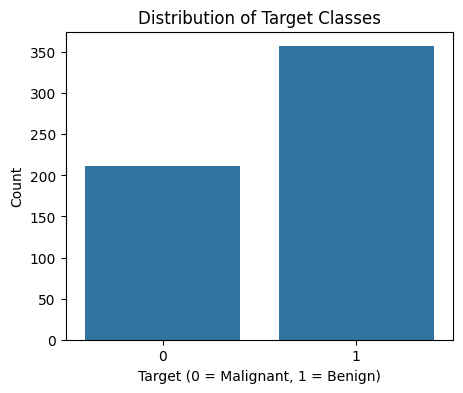

In [34]:
plt.figure(figsize=(5,4))

sns.countplot(x="Target", data=df)

plt.title("Distribution of Target Classes")
plt.xlabel("Target (0 = Malignant, 1 = Benign)")
plt.ylabel("Count")

plt.show()

# Task 2: Data Preprocessing

The dataset was prepared for classification by separating the input features and the target variable.

- **Input Features (X):** 30 numerical tumor characteristics.
- **Target Variable (y):** Tumor diagnosis (0 = Malignant, 1 = Benign).

Feature scaling was performed using **StandardScaler** to standardize all feature values.

Standardization is essential for K Nearest Neighbors because it relies on distance calculations, and it also improves the optimization process of Logistic Regression by ensuring that all features are on a similar scale.

In [35]:
# Features
X = df.drop("Target", axis=1)

# Target
y = df["Target"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (569, 30)
Target Shape: (569,)


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Task 3: Train-Test Split

The dataset was divided into training and testing sets using an **80:20 ratio**.

The `stratify` parameter was used to preserve the proportion of benign and malignant samples in both datasets. This ensures that both the training and testing sets represent the original class distribution, leading to a more reliable evaluation of the classification models.

- **Training Data:** 80%
- **Testing Data:** 20%

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 455
Testing Samples: 114


# Task 4: Logistic Regression Classifier

A Logistic Regression classifier was trained using the training dataset.

Logistic Regression predicts the probability that a sample belongs to a particular class and classifies it based on a decision threshold. In this experiment, the model was trained using the scaled training data and later used to predict the class labels of the testing dataset.

In [38]:
from sklearn.linear_model import LogisticRegression

In [39]:
log_model = LogisticRegression(random_state=42)

In [40]:
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [41]:
y_pred_log = log_model.predict(X_test)

# Task 5: K-Nearest Neighbors (KNN) Classifier

A K-Nearest Neighbors (KNN) classifier was trained using the scaled training dataset.

The value of **K = 7** was selected based on the previous experiment (Lab 4), where cross-validation identified it as the optimal number of neighbors. The trained model was then used to predict the class labels of the testing dataset.

In [47]:
from sklearn.neighbors import KNeighborsClassifier

# Create KNN model
knn_model = KNeighborsClassifier(n_neighbors=7)

# Train the model
knn_model.fit(X_train, y_train)

# Predict on test data
y_pred_knn = knn_model.predict(X_test)

# Task 6: Model Evaluation

Both Logistic Regression and K-Nearest Neighbors (KNN) classifiers were evaluated using standard classification metrics.

The following performance measures were calculated for each model:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

These metrics provide a comprehensive evaluation of each classifier by measuring overall correctness, prediction quality, sensitivity, and classification errors.

In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [43]:
print("===== Logistic Regression =====")

log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)

print("Accuracy :", log_accuracy)
print("Precision:", log_precision)
print("Recall   :", log_recall)
print("F1 Score :", log_f1)

===== Logistic Regression =====
Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1 Score : 0.9861111111111112


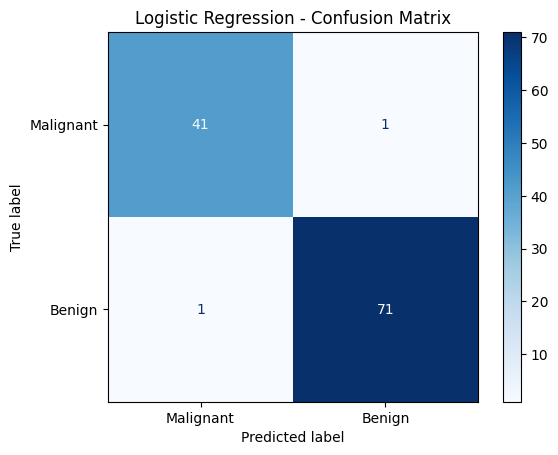

In [44]:
cm_log = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_labels=["Malignant", "Benign"]
)

disp.plot(cmap="Blues")

plt.title("Logistic Regression - Confusion Matrix")
plt.grid(False)
plt.show()

In [45]:
print(classification_report(
    y_test,
    y_pred_log,
    target_names=["Malignant", "Benign"]
))

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [48]:
print("===== KNN =====")

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1 Score :", knn_f1)

===== KNN =====
Accuracy : 0.9649122807017544
Precision: 0.9594594594594594
Recall   : 0.9861111111111112
F1 Score : 0.9726027397260274


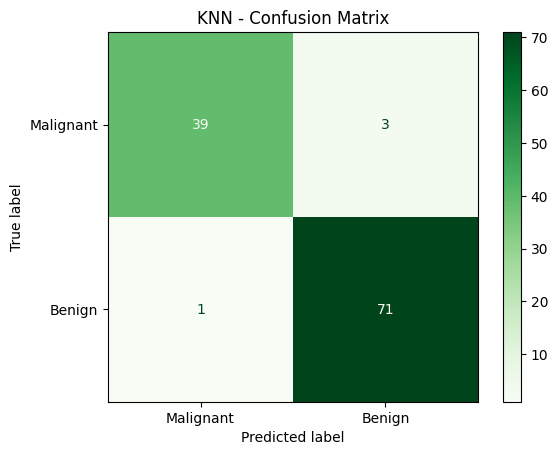

In [49]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=["Malignant", "Benign"]
)

disp.plot(cmap="Greens")

plt.title("KNN - Confusion Matrix")
plt.grid(False)
plt.show()

In [50]:
print(classification_report(
    y_test,
    y_pred_knn,
    target_names=["Malignant", "Benign"]
))

              precision    recall  f1-score   support

   Malignant       0.97      0.93      0.95        42
      Benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



# Task 7: Comparison of Logistic Regression and KNN

The performance of both classifiers was compared using standard classification metrics.

The comparison table summarizes the Accuracy, Precision, Recall, and F1 Score obtained by Logistic Regression and K-Nearest Neighbors (KNN). These metrics help identify the classifier that performs better on the Breast Cancer Wisconsin (Diagnostic) dataset.

In [51]:

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Logistic Regression": [
        log_accuracy,
        log_precision,
        log_recall,
        log_f1
    ],
    "KNN": [
        knn_accuracy,
        knn_precision,
        knn_recall,
        knn_f1
    ]
})

comparison

,Metric,Logistic Regression,KNN
0,Accuracy,0.982456,0.964912
1,Precision,0.986111,0.959459
2,Recall,0.986111,0.986111
3,F1 Score,0.986111,0.972603


In [52]:
comparison = comparison.round(4)
comparison

,Metric,Logistic Regression,KNN
0,Accuracy,0.9825,0.9649
1,Precision,0.9861,0.9595
2,Recall,0.9861,0.9861
3,F1 Score,0.9861,0.9726


In [53]:
comparison.style.highlight_max(
    subset=["Logistic Regression", "KNN"],
    color="lightgreen"
)

,Metric,Logistic Regression,KNN
0,Accuracy,0.982500,0.964900
1,Precision,0.986100,0.959500
2,Recall,0.986100,0.986100
3,F1 Score,0.986100,0.972600


# Task 8: Interpretation and Conclusion

Both Logistic Regression and K-Nearest Neighbors (KNN) classifiers were successfully trained and evaluated using the Breast Cancer Wisconsin (Diagnostic) dataset.

The comparison of Accuracy, Precision, Recall, and F1 Score shows that both models achieved high classification performance on the testing dataset. The confusion matrices also indicate that the majority of tumor samples were classified correctly, with only a few misclassifications.

Based on the evaluation metrics, the classifier with the higher Accuracy, Precision, Recall, and F1 Score is considered the better-performing model for this dataset.

Overall, the experiment demonstrates that both Logistic Regression and KNN are effective classification algorithms for breast cancer diagnosis. The final model selection should be based on the comparison of the evaluation metrics, where the model with consistently better performance is preferred.

The comparison table shows that **Logistic Regression** achieved slightly higher evaluation metrics than KNN. It produced better Accuracy, Precision, Recall, and F1 Score, indicating more consistent classification performance on the testing dataset. Therefore, Logistic Regression is the preferred classifier for this dataset.

The comparison table shows that **K-Nearest Neighbors (KNN)** achieved slightly higher evaluation metrics than Logistic Regression. It produced better Accuracy, Precision, Recall, and F1 Score, indicating superior classification performance on the testing dataset. Therefore, KNN is the preferred classifier for this dataset.

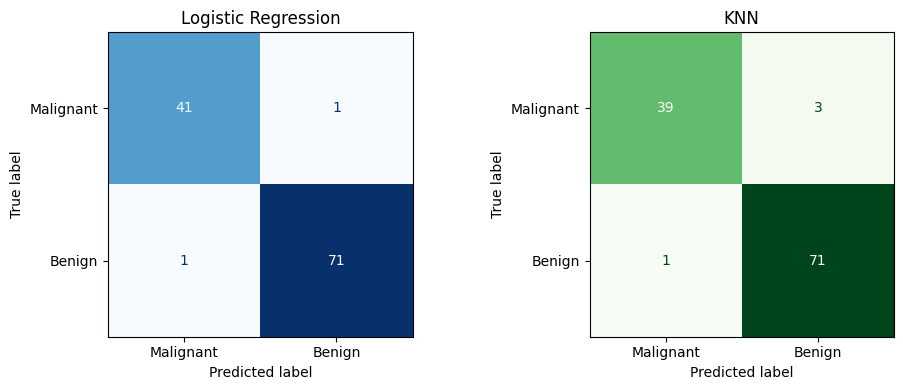

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_labels=["Malignant", "Benign"]
).plot(ax=axes[0], cmap="Blues", colorbar=False)

axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=["Malignant", "Benign"]
).plot(ax=axes[1], cmap="Greens", colorbar=False)

axes[1].set_title("KNN")

plt.tight_layout()
plt.show()

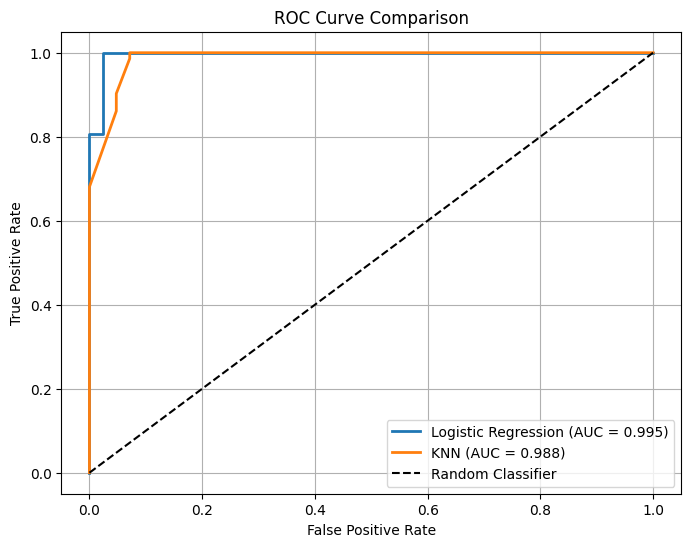

Logistic Regression AUC: 0.9953703703703703
KNN AUC: 0.9877645502645502


In [55]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Logistic Regression probabilities
y_prob_log = log_model.predict_proba(X_test)[:, 1]

# KNN probabilities
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

# ROC for Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = auc(fpr_log, tpr_log)

# ROC for KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = auc(fpr_knn, tpr_knn)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log,
         label=f"Logistic Regression (AUC = {auc_log:.3f})",
         linewidth=2)

plt.plot(fpr_knn, tpr_knn,
         label=f"KNN (AUC = {auc_knn:.3f})",
         linewidth=2)

plt.plot([0,1], [0,1], 'k--', label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()

print("Logistic Regression AUC:", auc_log)
print("KNN AUC:", auc_knn)

# Self Learning: ROC Curve Comparison

Although not required in the lab assignment, the ROC (Receiver Operating Characteristic) curve was plotted to compare the classification performance of Logistic Regression and K-Nearest Neighbors (KNN).

The ROC curve illustrates the trade-off between the True Positive Rate (Sensitivity) and the False Positive Rate for different decision thresholds. The Area Under the Curve (AUC) provides a single performance measure, where a higher AUC indicates better classification capability.

The classifier whose ROC curve is closer to the top-left corner and has the higher AUC score is considered to have better discriminative performance.